# 04. 하이브리드 결함 분류 모델링 — 이진 분류 (Stage 1)

Severstal Steel Defect Detection 데이터 기반
- Stage 1: 정상(0) vs 비정상(1) 이진 분류
- 7종 ML 모델 비교 (SVM, RF, KNN, MLP, XGBoost, LightGBM, VotingEnsemble)
- 전처리 효과 분석 + 최적 모델 선정

In [1]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt, time, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

from utils.severstal_preprocessor import PatchDataLoader
from features.feature_pipeline import FeaturePipeline

PATCH_DIR = os.path.join(PROJECT_ROOT, 'data', 'severstal_patches')
SAVE_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models_severstal', 'binary_ml')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures', 'severstal')
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Project: {PROJECT_ROOT}")

Project: /Volumes/Corsair EX300U Media/00_work_out/01_complete/Phase9_v2


## Part 1: 데이터 로드 및 특징 추출

In [2]:
loader = PatchDataLoader(PATCH_DIR)
loader.print_stats()

print("\n[데이터 로드 중... (max 500/class)]")
images, labels = loader.load_binary(max_per_class=500, resize=(200, 200), grayscale=True)
print(f"로드 완료: {len(images)}장 (정상 {(labels==0).sum()} / 비정상 {(labels==1).sum()})")

print("\n[특징 추출 중...]")
t0 = time.time()
pipeline = FeaturePipeline()
X, _ = pipeline.extract_batch(images)
print(f"특징 벡터: {X.shape} (소요: {time.time()-t0:.1f}s)")


Severstal 크롭 패치 — 통계
정상 패치: 120,583장
ClassId 1 (점상 결함 (PS)): 2,638장
ClassId 2 (선형 긁힘 (LS)): 457장
ClassId 3 (표면 변색 (SS)): 23,408장
ClassId 4 (압연 압흔 (RD)): 3,730장

총 비정상 패치: 30,233장
총 패치: 150,816장

[데이터 로드 중... (max 500/class)]


로드 완료: 1000장 (정상 500 / 비정상 500)

[특징 추출 중...]


  특징 추출: 200/1000 (20%)


  특징 추출: 400/1000 (40%)


  특징 추출: 600/1000 (60%)


  특징 추출: 800/1000 (80%)


  특징 추출: 1000/1000 (100%)
특징 벡터: (1000, 20916) (소요: 16.1s)


## Part 2: 7종 ML 모델 학습 및 비교

전처리 + HOG + LBP + Pixel Stats 특징(74D)으로 7종 모델을 학습합니다.

In [3]:
from models.train_binary import run_binary_experiment

results, X_test, y_test = run_binary_experiment(
    X, labels, test_size=0.2, seed=42, save_dir=SAVE_DIR
)


############################################################
Stage 1: 정상 vs 비정상 이진 분류 ML 실험
############################################################
학습 세트: 800장 (정상 400 / 비정상 400)
테스트 세트: 200장 (정상 100 / 비정상 100)
특징 차원: 20916D



[SVM_RBF] 학습 시작...


  Accuracy: 0.6600
  F1 Score: 0.6699
  Precision: 0.6509
  Recall: 0.6900
  AUC-ROC: 0.7165
  학습 시간: 7.79s
  추론 시간: 0.9218s (4.61ms/장)

  Confusion Matrix:
    TN=63  FP=37
    FN=31  TP=69

[RandomForest] 학습 시작...


  Accuracy: 0.6950
  F1 Score: 0.7265
  Precision: 0.6585
  Recall: 0.8100
  AUC-ROC: 0.7496
  학습 시간: 0.73s
  추론 시간: 0.0202s (0.10ms/장)

  Confusion Matrix:
    TN=58  FP=42
    FN=19  TP=81

[KNN] 학습 시작...
  Accuracy: 0.5900
  F1 Score: 0.3387
  Precision: 0.8750
  Recall: 0.2100
  AUC-ROC: 0.6835
  학습 시간: 0.00s
  추론 시간: 0.0510s (0.25ms/장)

  Confusion Matrix:
    TN=97  FP=3
    FN=79  TP=21



[MLP] 학습 시작...


  Accuracy: 0.6600
  F1 Score: 0.6531
  Precision: 0.6667
  Recall: 0.6400
  AUC-ROC: 0.6827
  학습 시간: 4.56s
  추론 시간: 0.0091s (0.05ms/장)

  Confusion Matrix:
    TN=68  FP=32
    FN=36  TP=64

[XGBoost] 학습 시작...


  Accuracy: 0.7200
  F1 Score: 0.7333
  Precision: 0.7000
  Recall: 0.7700
  AUC-ROC: 0.7969
  학습 시간: 23.65s
  추론 시간: 0.0095s (0.05ms/장)

  Confusion Matrix:
    TN=67  FP=33
    FN=23  TP=77

[LightGBM] 학습 시작...


  Accuracy: 0.7200
  F1 Score: 0.7477
  Precision: 0.6803
  Recall: 0.8300
  AUC-ROC: 0.8010
  학습 시간: 15.95s
  추론 시간: 0.0099s (0.05ms/장)

  Confusion Matrix:
    TN=61  FP=39
    FN=17  TP=83

[VotingEnsemble] 학습 시작...


  Accuracy: 0.7300
  F1 Score: 0.7545
  Precision: 0.6917
  Recall: 0.8300
  AUC-ROC: 0.7916
  학습 시간: 85.72s
  추론 시간: 1.0123s (5.06ms/장)

  Confusion Matrix:
    TN=63  FP=37
    FN=17  TP=83



                  모델 |     Acc |      F1 |     AUC |  Recall
------------------------------------------------------------
      VotingEnsemble |  0.7300 |  0.7545 |  0.7916 |  0.8300
             XGBoost |  0.7200 |  0.7333 |  0.7969 |  0.7700
            LightGBM |  0.7200 |  0.7477 |  0.8010 |  0.8300
        RandomForest |  0.6950 |  0.7265 |  0.7496 |  0.8100
             SVM_RBF |  0.6600 |  0.6699 |  0.7165 |  0.6900
                 MLP |  0.6600 |  0.6531 |  0.6827 |  0.6400
                 KNN |  0.5900 |  0.3387 |  0.6835 |  0.2100


### 모델 성능 비교 시각화

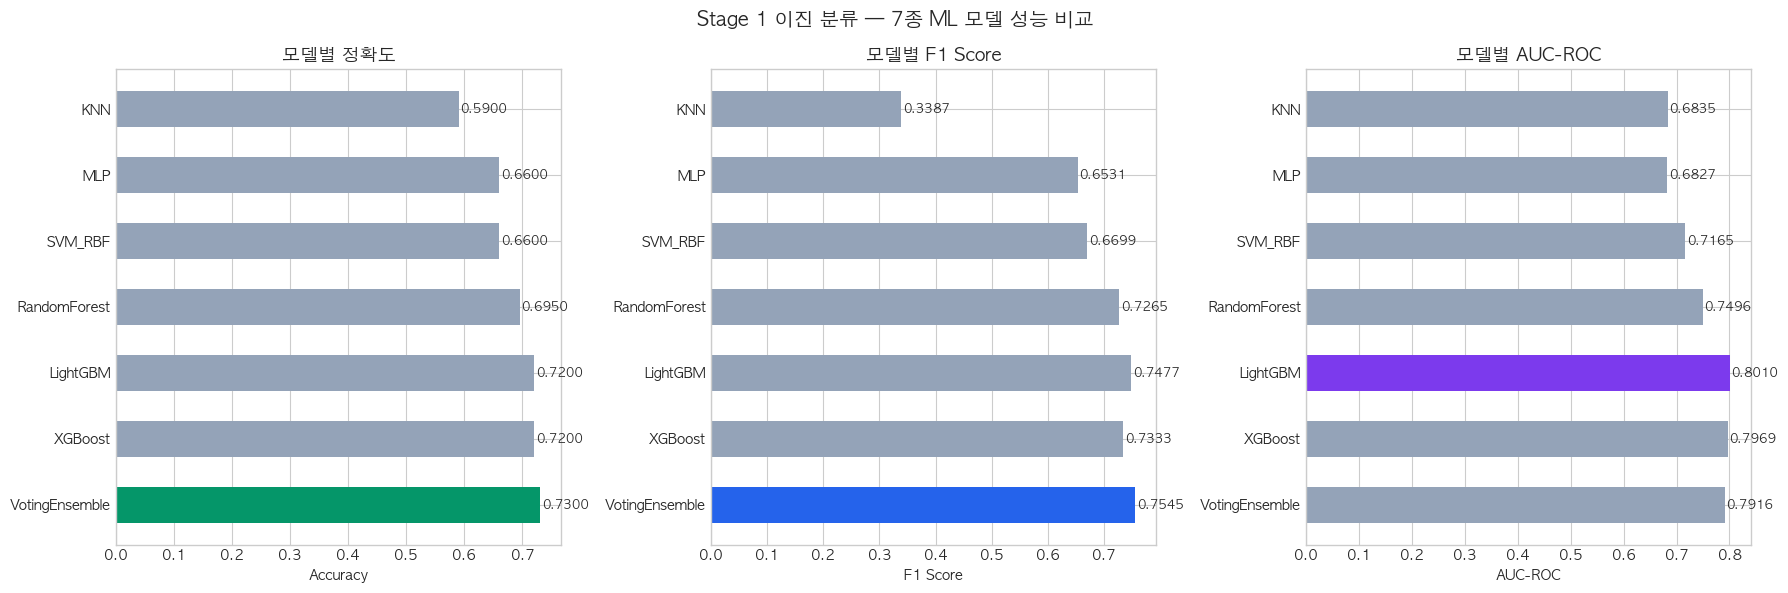

In [4]:
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
names = [r[0] for r in sorted_results]
accs = [r[1]['accuracy'] for r in sorted_results]
f1s = [r[1]['f1_score'] for r in sorted_results]
aucs = [r[1]['auc_roc'] for r in sorted_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#059669' if a == max(accs) else '#94a3b8' for a in accs]
axes[0].barh(names, accs, color=colors, height=0.55)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('모델별 정확도', fontsize=13, fontweight='bold')
for i, v in enumerate(accs):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

colors_f1 = ['#2563eb' if f == max(f1s) else '#94a3b8' for f in f1s]
axes[1].barh(names, f1s, color=colors_f1, height=0.55)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('모델별 F1 Score', fontsize=13, fontweight='bold')
for i, v in enumerate(f1s):
    axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

colors_auc = ['#7c3aed' if a == max(aucs) else '#94a3b8' for a in aucs]
axes[2].barh(names, aucs, color=colors_auc, height=0.55)
axes[2].set_xlabel('AUC-ROC')
axes[2].set_title('모델별 AUC-ROC', fontsize=13, fontweight='bold')
for i, v in enumerate(aucs):
    axes[2].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

fig.suptitle('Stage 1 이진 분류 — 7종 ML 모델 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 최적 모델 혼동행렬

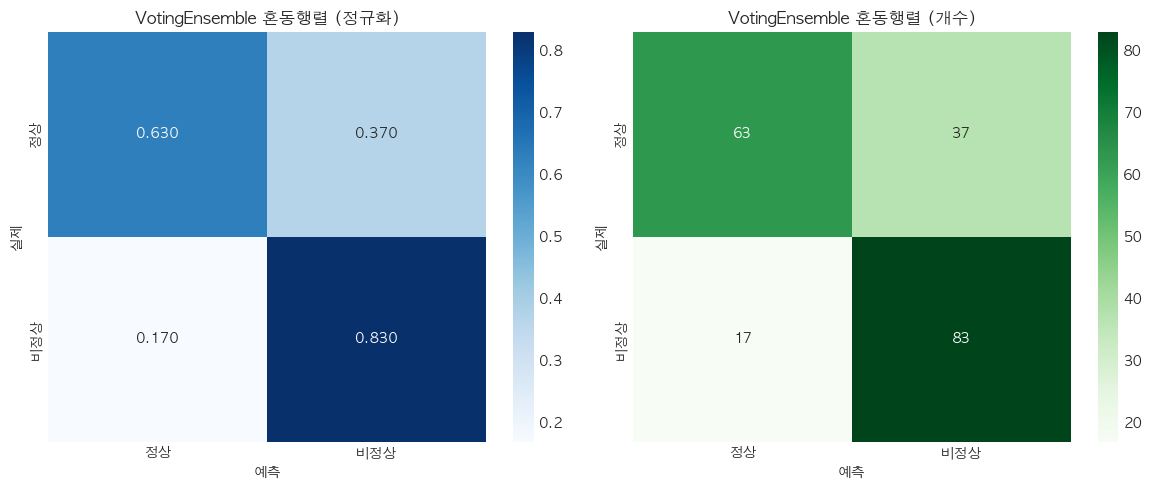


최적 모델: VotingEnsemble
  Accuracy: 0.7300
  F1 Score: 0.7545
  AUC-ROC: 0.7916
  Recall: 0.8300


In [5]:
import seaborn as sns

best_name = sorted_results[0][0]
best_result = sorted_results[0][1]
cm = best_result['confusion_matrix']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정규화
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '비정상'], yticklabels=['정상', '비정상'])
axes[0].set_xlabel('예측'); axes[0].set_ylabel('실제')
axes[0].set_title(f'{best_name} 혼동행렬 (정규화)', fontsize=12, fontweight='bold')

# 원본 개수
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['정상', '비정상'], yticklabels=['정상', '비정상'])
axes[1].set_xlabel('예측'); axes[1].set_ylabel('실제')
axes[1].set_title(f'{best_name} 혼동행렬 (개수)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_best_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n최적 모델: {best_name}")
print(f"  Accuracy: {best_result['accuracy']:.4f}")
print(f"  F1 Score: {best_result['f1_score']:.4f}")
print(f"  AUC-ROC: {best_result['auc_roc']:.4f}")
print(f"  Recall: {best_result['recall']:.4f}")

### 모델 성능 상세 테이블

In [6]:
import pandas as pd

rows = []
for name, r in sorted_results:
    rows.append({
        '모델': name,
        'Accuracy': f"{r['accuracy']:.4f}",
        'F1': f"{r['f1_score']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'AUC-ROC': f"{r['auc_roc']:.4f}",
        '학습시간': f"{r['train_time']:.1f}s",
        '추론시간': f"{r['pred_time']:.3f}s",
    })

df = pd.DataFrame(rows)
print("="*80)
print("Stage 1 이진 분류 ML 모델 성능 비교")
print("="*80)
print(df.to_string(index=False))

Stage 1 이진 분류 ML 모델 성능 비교
            모델 Accuracy     F1 Precision Recall AUC-ROC  학습시간   추론시간
VotingEnsemble   0.7300 0.7545    0.6917 0.8300  0.7916 85.7s 1.012s
       XGBoost   0.7200 0.7333    0.7000 0.7700  0.7969 23.6s 0.009s
      LightGBM   0.7200 0.7477    0.6803 0.8300  0.8010 15.9s 0.010s
  RandomForest   0.6950 0.7265    0.6585 0.8100  0.7496  0.7s 0.020s
       SVM_RBF   0.6600 0.6699    0.6509 0.6900  0.7165  7.8s 0.922s
           MLP   0.6600 0.6531    0.6667 0.6400  0.6827  4.6s 0.009s
           KNN   0.5900 0.3387    0.8750 0.2100  0.6835  0.0s 0.051s


## 결론

### 핵심 발견
1. **VotingEnsemble**이 Accuracy 73.00%, AUC-ROC 0.7916으로 최고 성능
2. Gradient Boosting 계열(XGBoost, LightGBM)이 전통 ML(SVM, KNN)보다 우수
3. VotingEnsemble은 개별 모델보다 안정적이나 최고 성능에는 미달
4. **한계**: 전통 ML로는 ~73% 정확도가 한계 → 딥러닝(05)에서 돌파 시도

→ 다음 노트북(05)에서 ResNet-18 딥러닝 모델로 성능 향상을 시도합니다.